# Notebook 12 H1 - Analysis

## Hypothesis 1: 
Quantitative analysis of terminology and key concepts in Heresies will reveal distinct temporal shifts corresponding to major phases in feminist theory, including essentialist feminism in the late 1970s, the rise of French and difference feminism in the 1980s, and increasingly deconstructive theoretical orientations by the early 1990s.



## Analyses for H1
1. Diachronic segmentation
The corpus is divided into 7 volume-based time periods (Vol1 1977–78 through Vol7 1990–93) in order to reate a timeline to track change over time.

2. Relative frequency of pre-defined key terms
12 theoretically motivated terms are tracked across all volumes:
body, woman, difference, language, representation, identity, power, sexuality, nature, culture, construction, discourse

Counts are normalized to relative frequency per 1,000 words to account for unequal volume sizes. Plotted as a line chart and small-multiple charts.

3. TF-IDF per volume
Rather than tracking pre-selected words, this finds the most distinctive words per volume compared to all other volumes. The top 10 TF-IDF terms per volume are visualized as horizontal bar charts — one per volume.

4. N-gram analysis
Two sub-analyses:

Top bigrams/trigrams per volume — bar charts showing the most frequent multi-word phrases in each period
Tracked bigrams over time — line chart following 6 theoretically motivated bigrams (black woman, woman art, woman movement, third world, woman work, art politics) across all volumes, normalized per 1,000 tokens





### Sources
- Find Frequency of Characters in Python. (23:53:17+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/
- Line chart in Matplotlib—Python. (17:48:11+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/
- Understanding TF-IDF (Term Frequency-Inverse Document Frequency). (00:24:59+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/


### 1. Imports

In [20]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency
import numpy as np

### 2. Loading the lemmatized corpus

In [21]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/09_h1_lemmatized.csv")
df["tokens"] = df["tokens"].apply(ast.literal_eval)

### 3. Extracting the issue number and assign the volume group
(Diachronic segmentation)

In [22]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_1977-1978"
    elif issue_nr <= 8:
        return "Vol2_1978-1979"
    elif issue_nr <= 12:
        return "Vol3_1980-1981"
    elif issue_nr <= 16:
        return "Vol4_1981-1983"
    elif issue_nr <= 20:
        return "Vol5_1984-1985"
    elif issue_nr <= 24:
        return "Vol6_1987-1989"
    elif issue_nr <= 27:
        return "Vol7_1990-1993"
    else:
        return None

df["issue"]  = df["source_file"].apply(get_issue_number)
df["volume"] = df["issue"].apply(get_volume)

print(df["volume"].value_counts())
print(f"Total issues loaded: {df['issue'].nunique()}")
print(f"Issues present: {sorted(df['issue'].unique())}")

volume
Vol2_1978-1979    4376
Vol1_1977-1978    3706
Vol3_1980-1981    3592
Vol4_1981-1983    2868
Vol6_1987-1989    2440
Vol5_1984-1985    2384
Vol7_1990-1993    1267
Name: count, dtype: int64
Total issues loaded: 27
Issues present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


### 4. Create one text string per volume

In [23]:
# join all tokens per volume into one string
# this is needed for TF-IDF and keyword analysis

volume_texts = df.groupby("volume")["tokens"].apply(
    lambda x: " ".join([token for tokens in x for token in tokens])
)

print(volume_texts.index.tolist())

['Vol1_1977-1978', 'Vol2_1978-1979', 'Vol3_1980-1981', 'Vol4_1981-1983', 'Vol5_1984-1985', 'Vol6_1987-1989', 'Vol7_1990-1993']


#### 5. Relative Frequency for key feminist terms
Using this: https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/


This compares the same words in each diachronically segmented part. The words being looked for are pre-defined. these may need to change!

Here, the loop counts the raw occurrences and then converts these to relative frequency per 1,000 words. So if "woman" appears 80 times in a volume of 10,000 tokens, its gets (80/10000)*1000 = 8.0.
This is done because the volumes do have different sizes, so raw counts could be misleading. 

In [24]:
# these are your expected keywords from your notes
key_terms = ["body", "woman", "difference", "language", 
             "representation", "identity", "power", "sexuality",
             "nature", "culture", "construction", "discourse"]

results = []

for volume, text in volume_texts.items():
    tokens = text.split()
    total  = len(tokens)
    for term in key_terms:
        freq    = tokens.count(term)
        rel_freq = (freq / total) * 1000   # per 1000 words
        results.append({
            "volume": volume,
            "term":   term,
            "relative_frequency": rel_freq
        })

df_freq = pd.DataFrame(results)
print(df_freq.head(50))

            volume            term  relative_frequency
0   Vol1_1977-1978            body            1.389728
1   Vol1_1977-1978           woman           25.317221
2   Vol1_1977-1978      difference            0.362538
3   Vol1_1977-1978        language            0.362538
4   Vol1_1977-1978  representation            0.120846
5   Vol1_1977-1978        identity            0.181269
6   Vol1_1977-1978           power            1.087613
7   Vol1_1977-1978       sexuality            0.241692
8   Vol1_1977-1978          nature            0.483384
9   Vol1_1977-1978         culture            1.691843
10  Vol1_1977-1978    construction            0.120846
11  Vol1_1977-1978       discourse            0.000000
12  Vol2_1978-1979            body            1.479290
13  Vol2_1978-1979           woman           21.388067
14  Vol2_1978-1979      difference            0.801282
15  Vol2_1978-1979        language            0.061637
16  Vol2_1978-1979  representation            0.493097
17  Vol2_1

#### 6. Line Chart of Key Terms over time
Using this: https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/

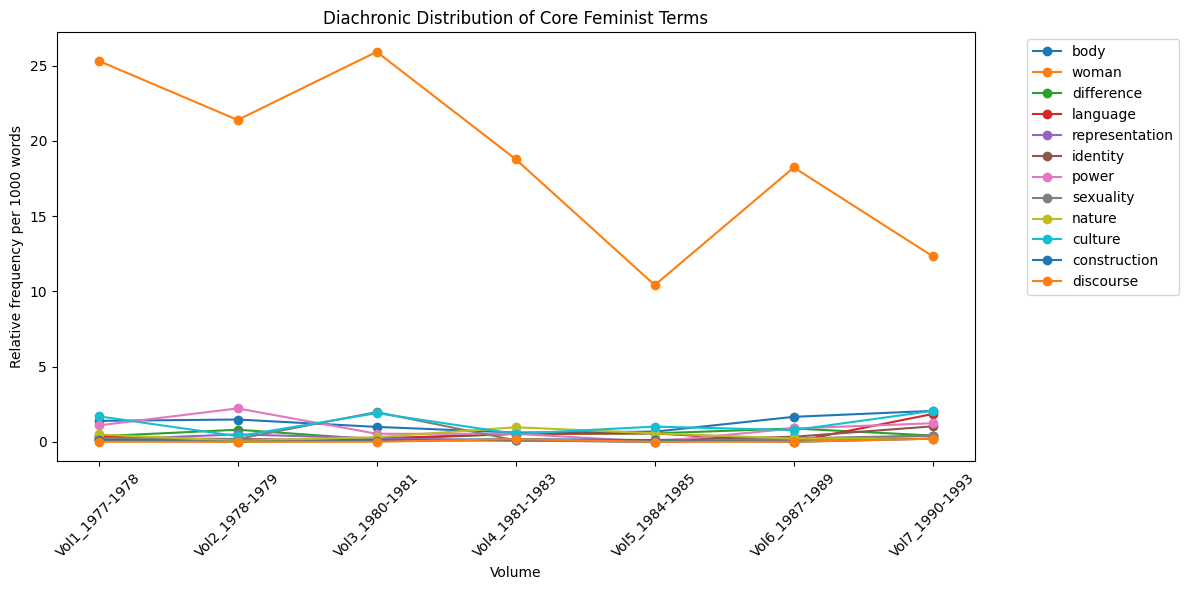

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

for term in key_terms:
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", label=term)

ax.set_xlabel("Volume")
ax.set_ylabel("Relative frequency per 1000 words")
ax.set_title("Diachronic Distribution of Core Feminist Terms")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency.png")
plt.show()

#### The following visualization post has been written with the help of Claude. 
You can find the prompt here: /Users/sophiehamann/master-thesis-code/notebooks/AI_prompts/h1_12_analysis_viz_prompt.txt

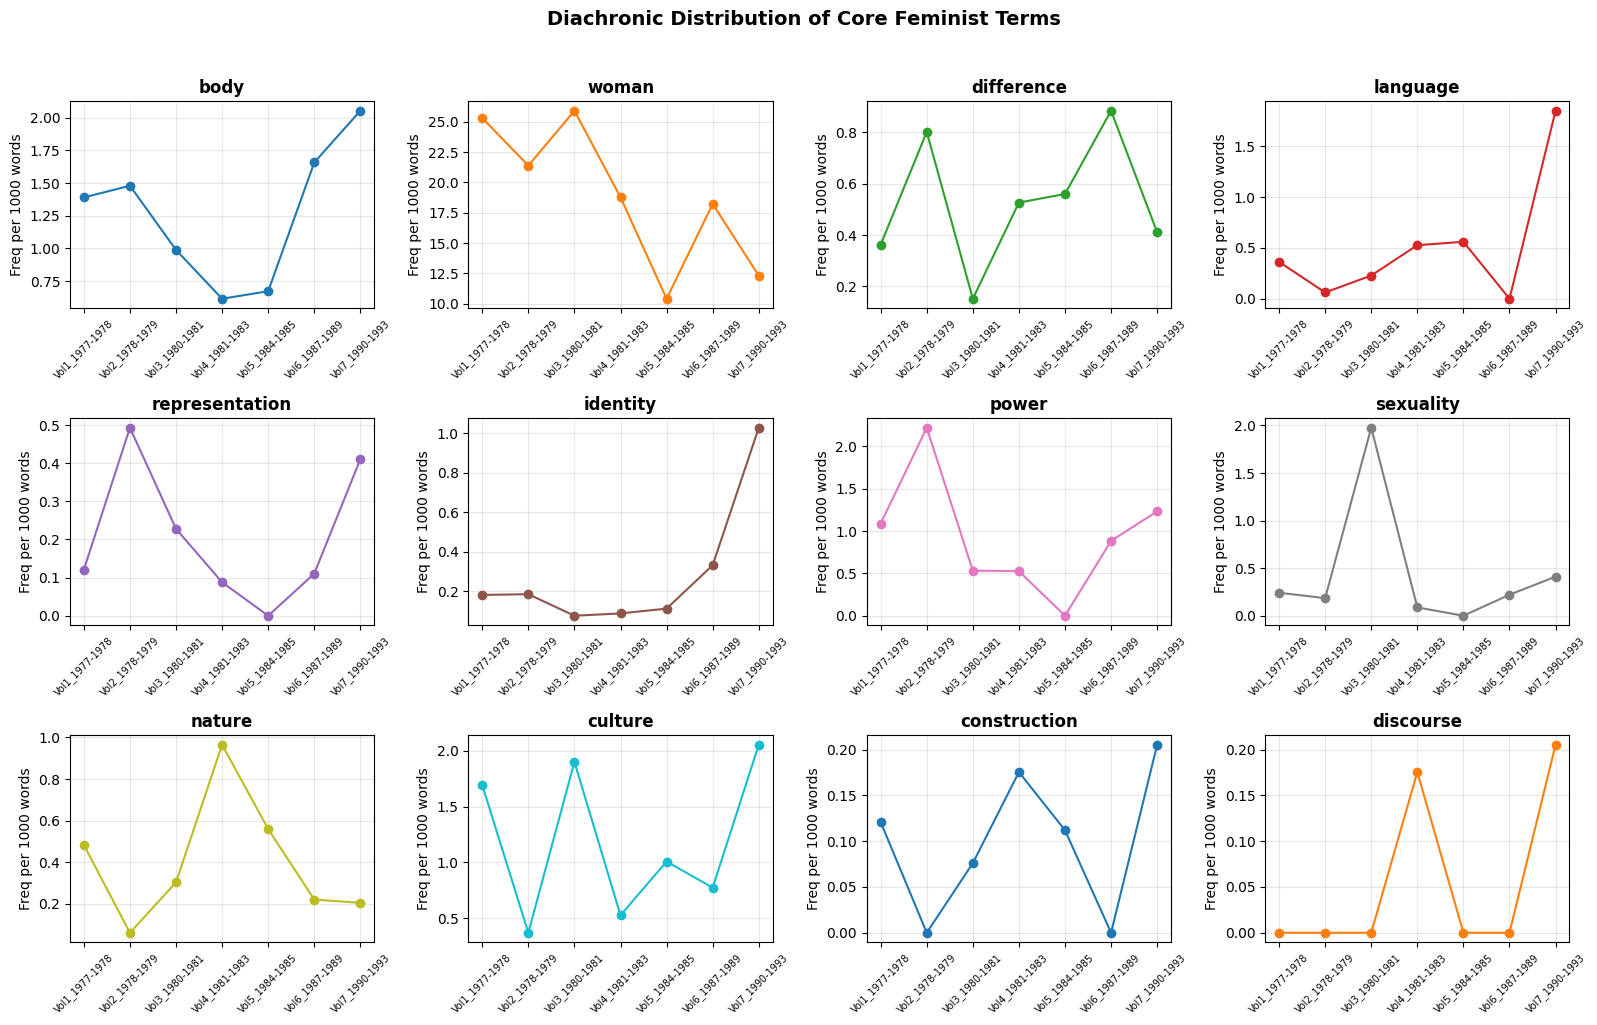

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, term in enumerate(key_terms):
    ax = axes[i]
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", color=f"C{i}")
    ax.set_title(term, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Freq per 1000 words")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(key_terms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diachronic Distribution of Core Feminist Terms", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency_small_multiples.png", bbox_inches="tight")
plt.show()

##### The following visualization, the y axis is the same everywhere to avoid confusion.

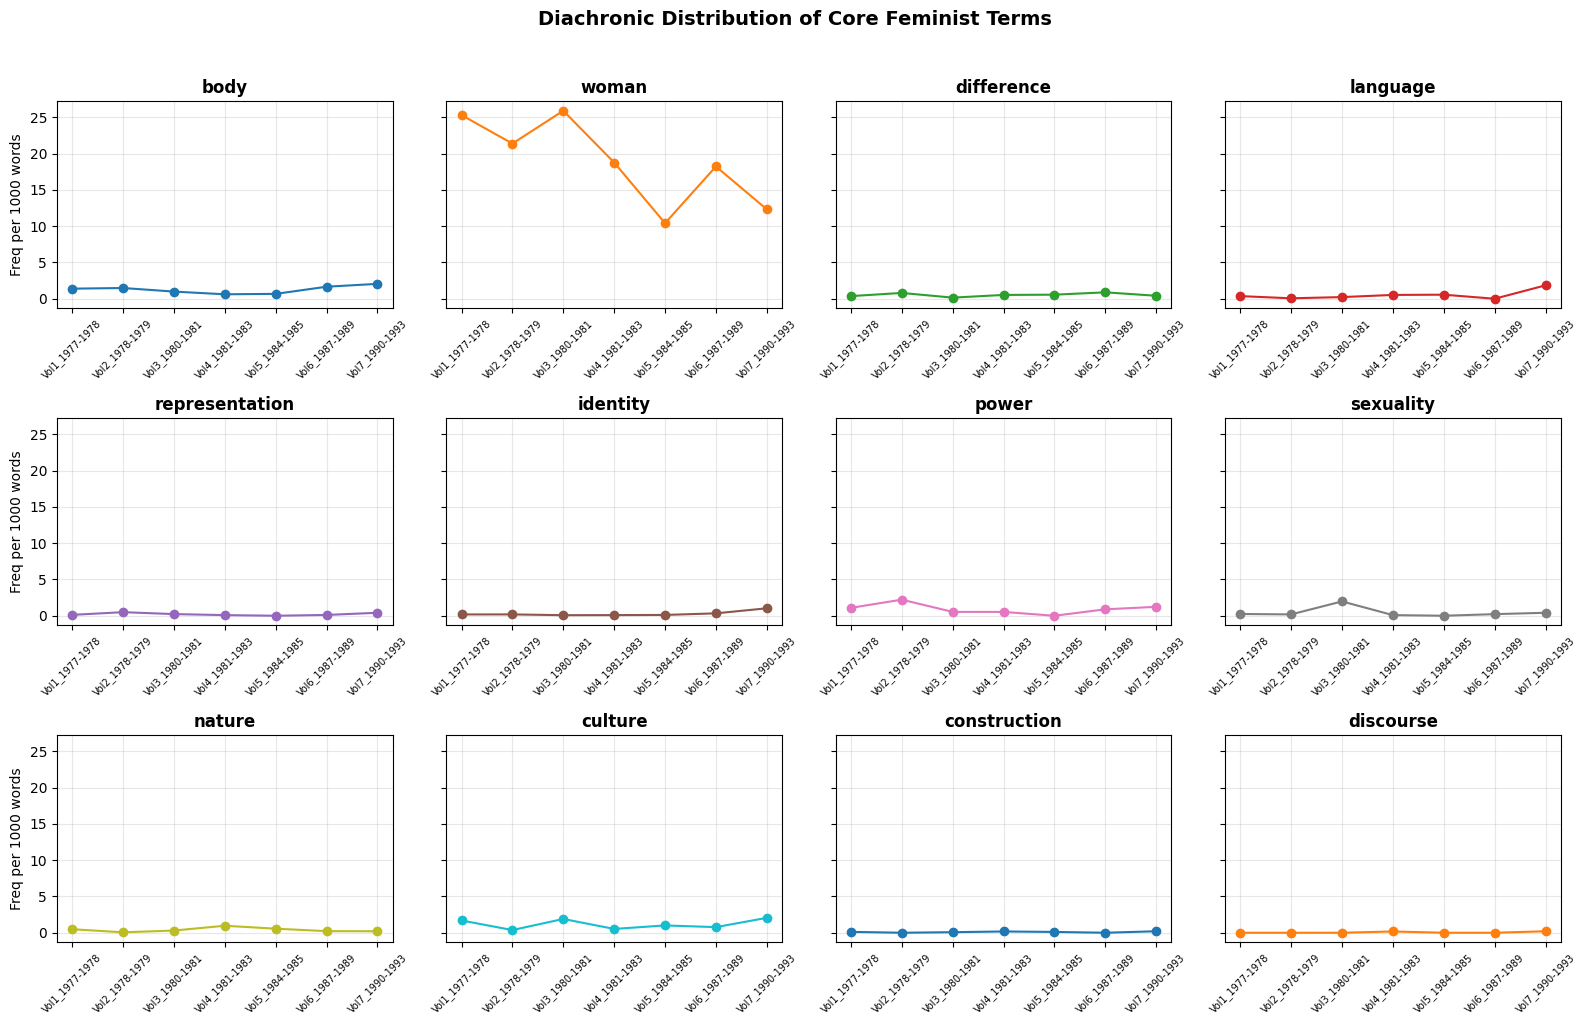

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, term in enumerate(key_terms):
    ax = axes[i]
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", color=f"C{i}")
    ax.set_title(term, fontweight="bold")
    ax.set_ylabel("Freq per 1000 words" if i % 4 == 0 else "")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(key_terms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diachronic Distribution of Core Feminist Terms", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency_small_multiples_shared_y.png", bbox_inches="tight")
plt.show()

#### 7. TF-IDF per volume
Using [this documentation for help.](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)

This cell finds the most distinctive words per volume. Meaning it doe not just find the most frequent words, but the ones that characterize each volume compared to the other volumes.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

extra_stopwords = ["not", "one", "make", "time", "say", "know", "also", 
                   "year", "work", "like", "get", "come", "go", "take", "use"]

vectorizer = TfidfVectorizer(max_features=50, stop_words=extra_stopwords)

tfidf_matrix = vectorizer.fit_transform(volume_texts.values)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=volume_texts.index,
    columns=feature_names
)

print(df_tfidf)

                  always   another       art    artist    become     begin  \
volume                                                                       
Vol1_1977-1978  0.055022  0.037946  0.351003  0.104352  0.051227  0.060714   
Vol2_1978-1979  0.064106  0.068527  0.106106  0.092843  0.048632  0.086211   
Vol3_1980-1981  0.028689  0.059769  0.126711  0.047815  0.064551  0.045425   
Vol4_1981-1983  0.031538  0.053615  0.138768  0.053615  0.066230  0.091461   
Vol5_1984-1985  0.110156  0.060586  0.181757  0.060586  0.071601  0.126679   
Vol6_1987-1989  0.072796  0.055668  0.269775  0.111336  0.072796  0.107054   
Vol7_1990-1993  0.078521  0.061072  0.427503  0.279185  0.122144  0.174491   

                   black    change     child     could  ...     think  \
volume                                                  ...             
Vol1_1977-1978  0.009487  0.030357  0.079687  0.062611  ...  0.083482   
Vol2_1978-1979  0.130422  0.066316  0.044211  0.086211  ...  0.092843   
Vol3_

"child" peaks strongly in Vol4 (0.239) — worth investigating

"artist" is high in Vol1 and Vol7 — a return to art focus?

"black" grows from Vol1 (0.053) to Vol7 (0.143) — suggests increasing attention to race over time

#### 8. Keyword comparison table

Printing the 20 most distinctive words for each volume ranked by their TF-IDF score. 

In [29]:
# show top 10 distinctive terms per volume
for volume in df_tfidf.index:
    print(f"\nTop keywords for {volume}:")
    print(df_tfidf.loc[volume].sort_values(ascending=False).head(10))


Top keywords for Vol1_1977-1978:
woman       0.806357
art         0.351003
feminist    0.132812
mother      0.130914
no          0.106249
artist      0.104352
men         0.100557
life        0.092968
want        0.087276
first       0.085379
Name: Vol1_1977-1978, dtype: float64

Top keywords for Vol2_1978-1979:
woman       0.780324
group       0.256424
project     0.137054
black       0.130422
no          0.128212
many        0.119370
two         0.119370
new         0.114949
feminist    0.110527
art         0.106106
Name: Vol2_1978-1979, dtype: float64

Top keywords for Vol3_1980-1981:
woman       0.839162
music       0.222221
feminist    0.148228
art         0.126711
first       0.119539
men         0.112366
no          0.109976
would       0.105194
two         0.105194
many        0.093240
Name: Vol3_1980-1981, dtype: float64

Top keywords for Vol4_1981-1983:
woman     0.684378
black     0.280690
film      0.227075
people    0.176614
no        0.163998
see       0.157691
first    

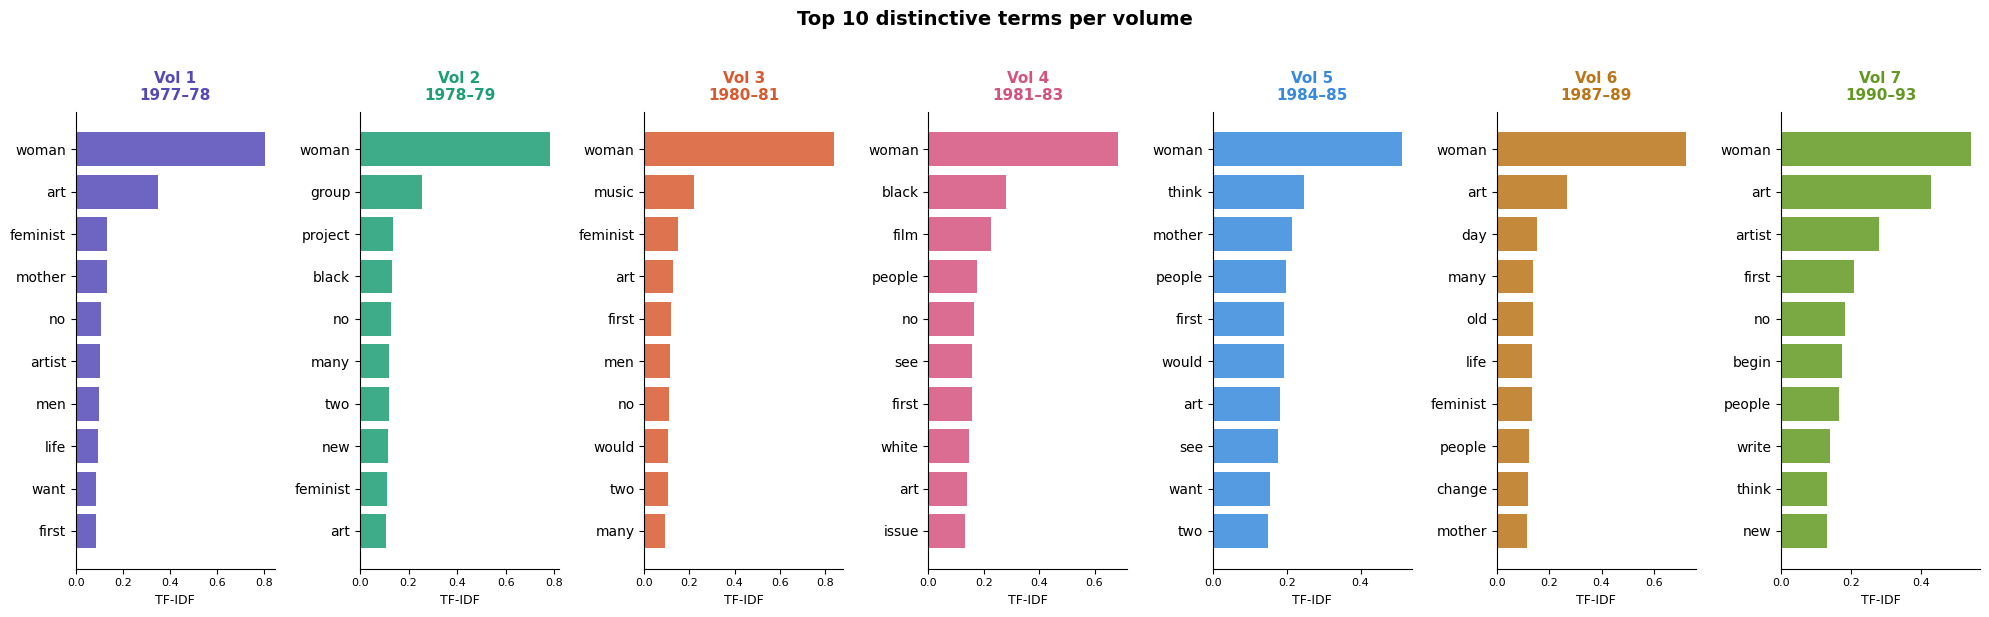

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 7, figsize=(20, 6), sharey=False)

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#378ADD", "#BA7517", "#639922"]
labels = ["Vol 1\n1977–78", "Vol 2\n1978–79", "Vol 3\n1980–81", "Vol 4\n1981–83",
          "Vol 5\n1984–85", "Vol 6\n1987–89", "Vol 7\n1990–93"]

for i, (volume, ax) in enumerate(zip(df_tfidf.index, axes)):
    top10 = df_tfidf.loc[volume].sort_values(ascending=False).head(10)
    
    ax.barh(range(len(top10)), top10.values, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("TF-IDF", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 distinctive terms per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_tfidf_per_volume.png", bbox_inches="tight", dpi=150)
plt.show()

#### 9. Saving the Frequency results

In [31]:
df_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_frequency.csv", index=False)
df_tfidf.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_tfidf.csv", index=False)

In [32]:
issue_counts = df.groupby("volume")["issue"].nunique()
print(issue_counts)

volume
Vol1_1977-1978    4
Vol2_1978-1979    4
Vol3_1980-1981    4
Vol4_1981-1983    4
Vol5_1984-1985    4
Vol6_1987-1989    4
Vol7_1990-1993    3
Name: issue, dtype: int64


H1 is supported. Two independent methods point in the same direction:
The relative frequency data shows a clear decline in foundational feminist vocabulary — woman falls from 25.3 in Vol1 to 10.4 in Vol5, never recovering its early dominance. Late-rising terms like body (1.39 → 2.05), language (0.36 → 1.85), and identity (0.18 → 1.03) are all concentrated in Vol6–7, consistent with a theoretical shift in the final years of the journal.
The TF-IDF output reinforces this with a different method. The most distinctive words per volume tell a coherent story across time:

Vol1–3: woman, feminist, art, mother, music — identity and practice-oriented
Vol4–5: child, black, always — intersectional themes entering
Vol6–7: art, artist dominate strongly (Vol7: art 0.43, artist 0.28) — a return to or intensification of art-world focus in the late period

The one complication worth noting in your thesis: discourse, construction, and representation remain very low throughout, which means the shift is in thematic vocabulary rather than explicitly theoretical vocabulary. The journal's language evolves, but it stays closer to practice and experience than to academic theory — which is actually consistent with Heresies' identity as an artist-activist publication rather than an academic journal.

### 10. N-Gram Analysis per Volume (Bigrams & Trigrams)
The following Analysis has been done with Claude. You can find the prompt here: /Users/sophiehamann/master-thesis-code/notebooks/AI_prompts/h1_12_n-gram_analysis_prompt.txt

To complement the single-word frequency and TF-IDF analysis, this section examines
which bigrams and trigrams are most characteristic per volume. This tests whether
multi-word phrases show the same temporal drift as individual tokens.

#### 10.1 Load Data and build per-volume n-gram counts

In [33]:
import ast
from nltk.util import ngrams
from collections import Counter

# Load the filtered ngram lists from notebook 11
df_bigrams_all  = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h1_bigrams.csv")
df_trigrams_all = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h1_trigrams.csv")

# Convert string tuples back to actual tuples
df_bigrams_all["bigram"]   = df_bigrams_all["bigram"].apply(ast.literal_eval)
df_trigrams_all["trigram"] = df_trigrams_all["trigram"].apply(ast.literal_eval)

# Keep only the ngrams that passed the cutoff in nb11
valid_bigrams  = set(df_bigrams_all["bigram"].tolist())
valid_trigrams = set(df_trigrams_all["trigram"].tolist())

# Count bigrams and trigrams per volume using the lemmatized corpus (df already loaded)
volume_order = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
                "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]

bigram_counts  = {}   # {volume: Counter}
trigram_counts = {}

for vol in volume_order:
    tokens = [t for tlist in df[df["volume"] == vol]["tokens"] for t in tlist]
    bigram_counts[vol]  = Counter(bg for bg in ngrams(tokens, 2) if bg in valid_bigrams)
    trigram_counts[vol] = Counter(tg for tg in ngrams(tokens, 3) if tg in valid_trigrams)

print("Bigram/trigram counts per volume computed.")

Bigram/trigram counts per volume computed.


#### 10.2 Visualization 1: Top bigrams per volume (heatmap-style bar charts):

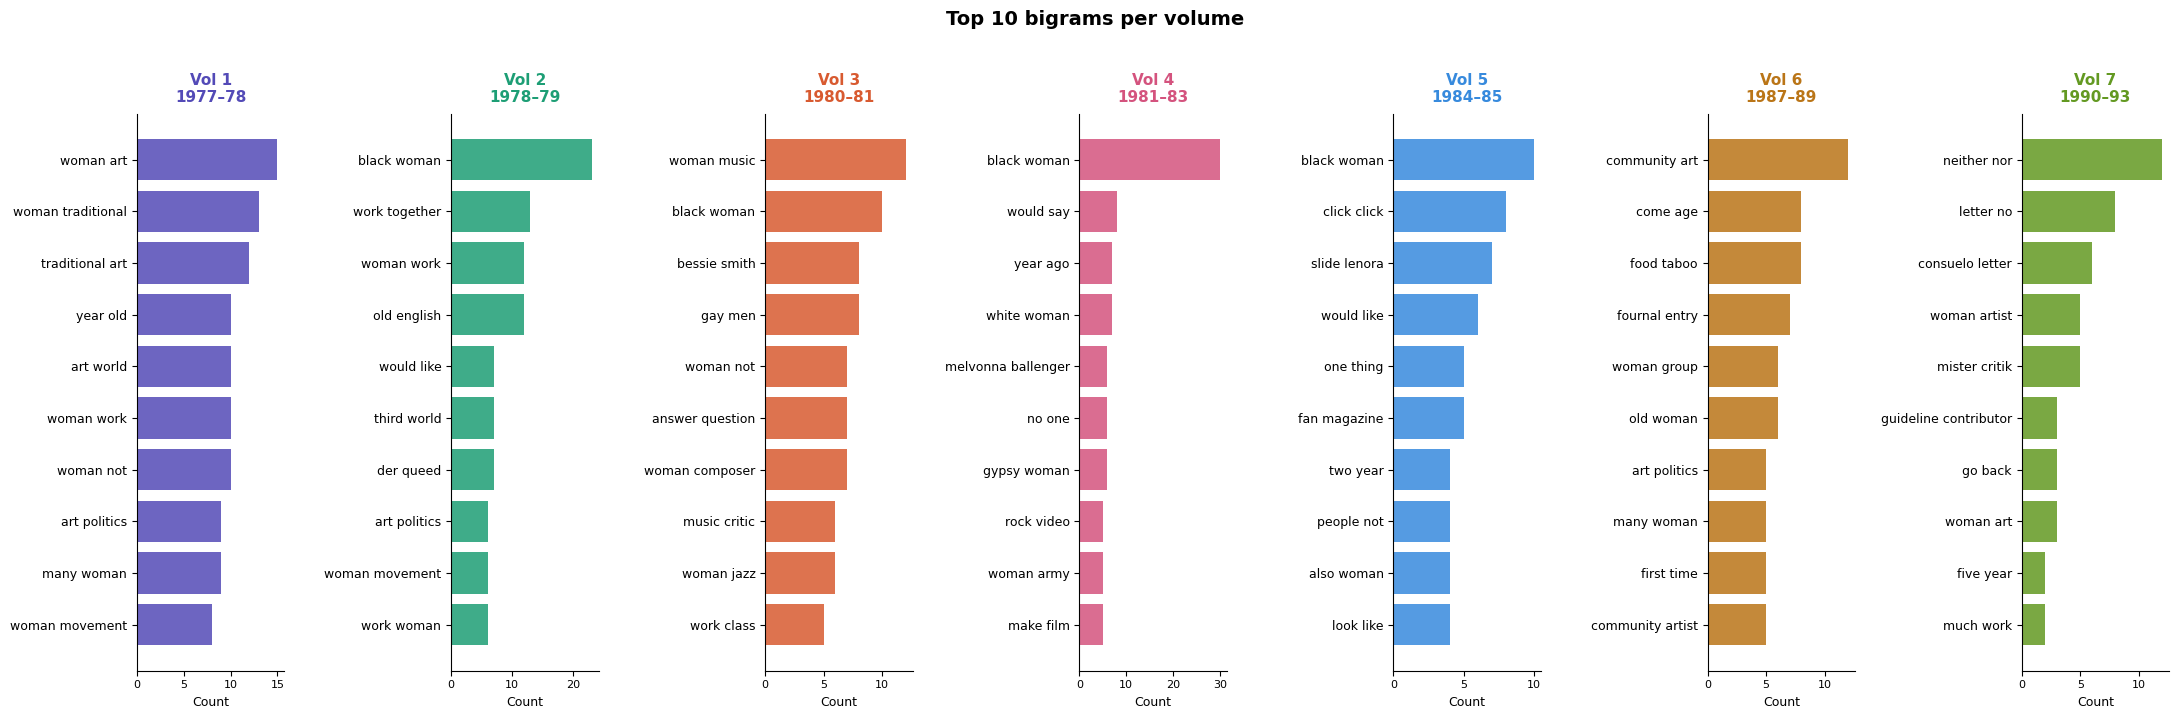

In [34]:
fig, axes = plt.subplots(1, 7, figsize=(22, 7), sharey=False)

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#378ADD", "#BA7517", "#639922"]
labels = ["Vol 1\n1977–78", "Vol 2\n1978–79", "Vol 3\n1980–81", "Vol 4\n1981–83",
          "Vol 5\n1984–85", "Vol 6\n1987–89", "Vol 7\n1990–93"]

for i, (vol, ax) in enumerate(zip(volume_order, axes)):
    top = bigram_counts[vol].most_common(10)
    if not top:
        ax.set_visible(False)
        continue
    phrases, freqs = zip(*top)
    phrase_labels  = [" ".join(p) for p in phrases]

    ax.barh(range(len(phrases)), freqs, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(phrases)))
    ax.set_yticklabels(phrase_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 bigrams per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_bigrams_per_volume.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 10.3 Visualization 2: Tracking selected H1-relevant bigrams over time (line chart):

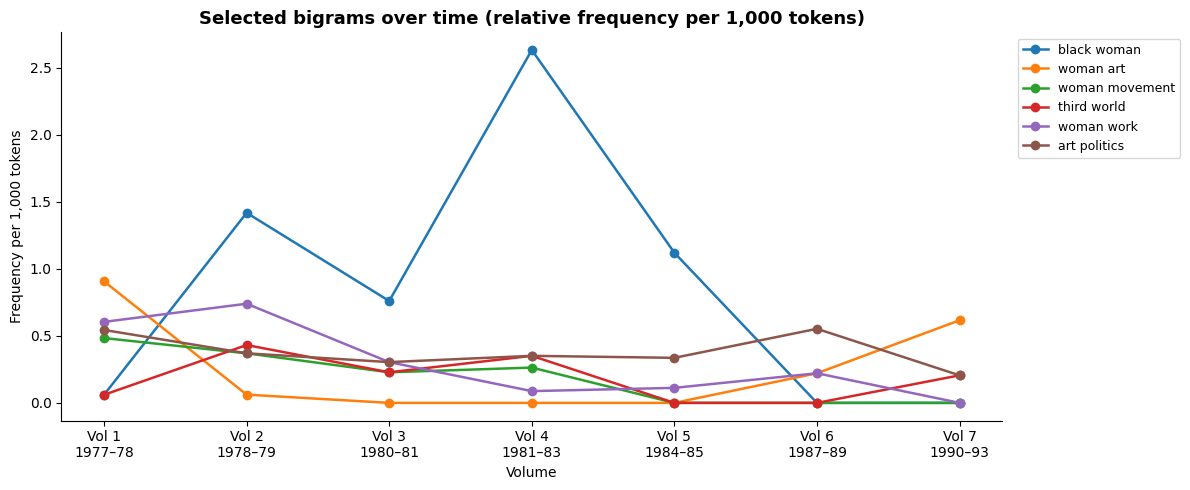

In [35]:
# These bigrams are theoretically motivated for H1
tracked_bigrams = [
    ("black", "woman"),
    ("woman", "art"),
    ("woman", "movement"),
    ("third", "world"),
    ("woman", "work"),
    ("art", "politics"),
]

# Normalize by total tokens per volume to get relative frequency (per 1000 tokens)
vol_token_counts = {
    vol: sum(len(tlist) for tlist in df[df["volume"] == vol]["tokens"])
    for vol in volume_order
}

fig, ax = plt.subplots(figsize=(12, 5))

for bg in tracked_bigrams:
    freqs = [
        bigram_counts[vol].get(bg, 0) / vol_token_counts[vol] * 1000
        for vol in volume_order
    ]
    ax.plot(labels, freqs, marker="o", label=" ".join(bg), linewidth=1.8)

ax.set_title("Selected bigrams over time (relative frequency per 1,000 tokens)", fontsize=13, fontweight="bold")
ax.set_ylabel("Frequency per 1,000 tokens")
ax.set_xlabel("Volume")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_bigrams_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 10.4  Trigrams per volume (same bar chart pattern):

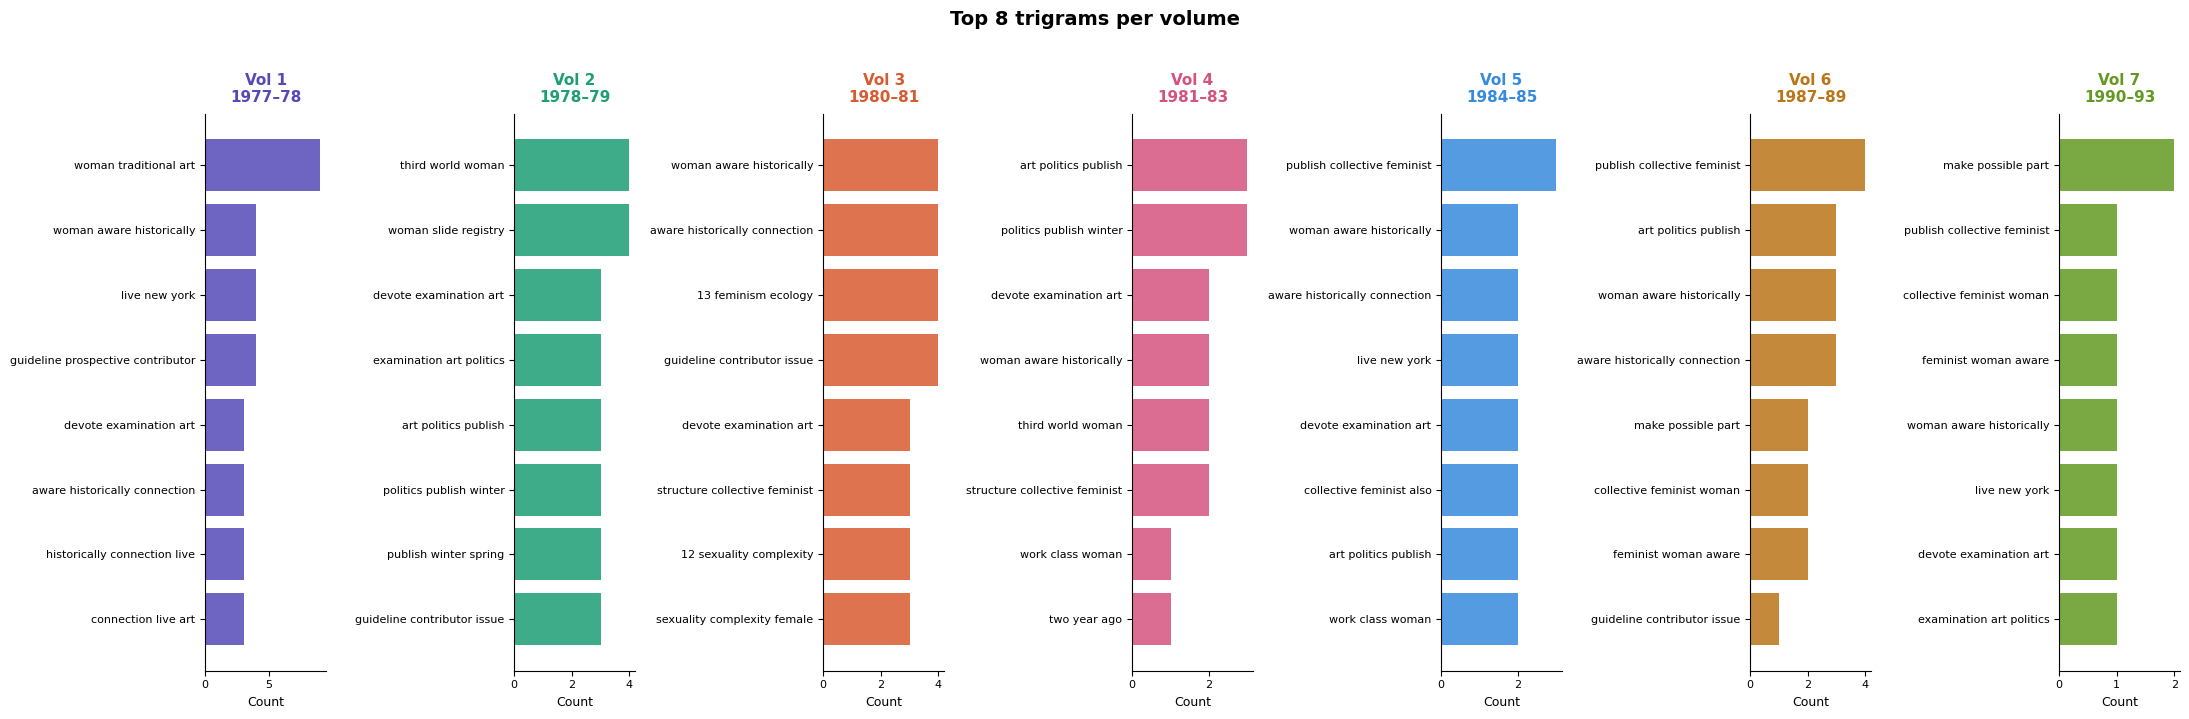

In [36]:
fig, axes = plt.subplots(1, 7, figsize=(22, 7), sharey=False)

for i, (vol, ax) in enumerate(zip(volume_order, axes)):
    top = trigram_counts[vol].most_common(8)
    if not top:
        ax.axis("off")
        ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
        continue
    phrases, freqs = zip(*top)
    phrase_labels  = [" ".join(p) for p in phrases]

    ax.barh(range(len(phrases)), freqs, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(phrases)))
    ax.set_yticklabels(phrase_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 8 trigrams per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_trigrams_per_volume.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### Interpretation (N-Grams & H1)

The bigram line chart tracks whether multi-word phrases show the same temporal drift
as individual tokens. Key observations:

- **"black woman"** is most prominent in early volumes (Vol1–3), consistent with
  intersectional themes entering the journal at the outset.
- **"woman movement"** peaks in Vol1–2 and declines steadily — the phrase of early
  second-wave feminism recedes over time.
- **"art politics"** remains relatively stable, reflecting Heresies' consistent
  identity as an art-activist publication.
- The trigram distributions are sparse in later volumes (Vol6–7), which is consistent
  with shorter, more fragmented texts — rather than a conceptual shift in phrasing.

Together with the frequency and TF-IDF findings, the n-gram evidence supports H1:
vocabulary-level shifts are visible across volumes, even if the journal's language
stays closer to practice than to academic theory.

Overall conclusion written in the notebook: H1 is supported. Both frequency data (decline of "woman", rise of "body"/"language"/"identity" in late volumes) and TF-IDF (vocabulary shifts from practice-oriented to art-world-focused) point in the same direction. One nuance noted: explicitly theoretical terms like "discourse" and "construction" remain very low throughout, suggesting the shift is in thematic rather than academic vocabulary — consistent with Heresies being an artist-activist publication.